# EfficientNetB0 Tomato Leaf Disease Classification
**Author:** We Can't Code  
**GitHub:** https://github.com/slyeet03/SmartSpray

In [1]:
import tensorflow as tf
from tensorflow import keras
from tensorflow.keras import layers, models, optimizers, callbacks
import numpy as np
import matplotlib.pyplot as plt
import os, cv2, random
from sklearn.model_selection import train_test_split
from collections import Counter
from sklearn.utils import class_weight
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay
import pandas as pd

tf.random.set_seed(42)
np.random.seed(42)
random.seed(42)
os.environ['TF_CPP_MIN_LOG_LEVEL'] = '2'

TRAIN_DIR = "archive/train/"
IMG_SIZE = 224
BATCH_SIZE = 32
EPOCHS = 100

In [2]:
data_augmentation = keras.Sequential([
    layers.RandomFlip("horizontal_and_vertical"),
    layers.RandomRotation(0.3),
    layers.RandomZoom(0.3),
    layers.RandomContrast(0.3),
])

In [3]:
def load_and_analyze_data():
    classes = sorted([i for i in os.listdir(TRAIN_DIR) if os.path.isdir(os.path.join(TRAIN_DIR, i))])
    class_to_idx = {cls_name: idx for idx, cls_name in enumerate(classes)}
    data, labels, class_counts, problematic_images = [], [], Counter(), []
    for class_name in classes:
        class_path = os.path.join(TRAIN_DIR, class_name)
        for img_name in os.listdir(class_path):
            img_path = os.path.join(class_path, img_name)
            img = cv2.imread(img_path, cv2.IMREAD_COLOR)
            if img is None or img.size == 0 or min(img.shape[:2]) < 50:
                problematic_images.append(img_path)
                continue
            img = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)
            img = cv2.resize(img, (IMG_SIZE, IMG_SIZE))
            img = img.astype(np.float32) / 255.0
            data.append(img)
            labels.append(class_to_idx[class_name])
            class_counts[class_name] += 1
    X, y = np.array(data), np.array(labels)
    X_train, X_val, y_train, y_val = train_test_split(X, y, test_size=0.2, stratify=y, random_state=42)
    return X_train, X_val, y_train, y_val, classes, class_counts

In [4]:
X_train, X_val, y_train, y_val, classes, class_counts = load_and_analyze_data()
class_weights = class_weight.compute_class_weight('balanced', classes=np.unique(y_train), y=y_train)
class_weights = dict(enumerate(class_weights))

In [5]:
def create_efficientnet(num_classes):
    base_model = keras.applications.EfficientNetB0(
        include_top=False,
        weights=None,  # train from scratch to avoid mismatch
        input_shape=(IMG_SIZE, IMG_SIZE, 3),
        pooling="avg"
    )
    base_model.trainable = True
    model = models.Sequential([
        layers.Input(shape=(IMG_SIZE, IMG_SIZE, 3)),
        data_augmentation,
        base_model,
        layers.Dropout(0.5),
        layers.Dense(num_classes, activation="softmax")
    ])
    return model, base_model

model, base_model = create_efficientnet(len(classes))
model.compile(optimizer=optimizers.Adam(learning_rate=0.001),
              loss="sparse_categorical_crossentropy",
              metrics=["accuracy"])

In [6]:
early_stopping = callbacks.EarlyStopping(monitor='val_accuracy', patience=15, restore_best_weights=True)
reduce_lr = callbacks.ReduceLROnPlateau(monitor='val_loss', factor=0.5, patience=8, min_lr=1e-7)
checkpoint = callbacks.ModelCheckpoint('best_model.keras', monitor='val_accuracy', save_best_only=True, mode='max')

history = model.fit(X_train, y_train, batch_size=BATCH_SIZE, epochs=EPOCHS,
                    validation_data=(X_val, y_val), class_weight=class_weights,
                    callbacks=[early_stopping, reduce_lr, checkpoint])

Epoch 1/100
408/408 ━━━━━━━━━━━━━━━━━━━━ 601s 1s/step - accuracy: 4.6030e-04 - loss: nan - val_accuracy: 0.0000e+00 - val_loss: nan - learning_rate: 0.0010
Epoch 2/100
408/408 ━━━━━━━━━━━━━━━━━━━━ 576s 1s/step - accuracy: 0.0000e+00 - loss: nan - val_accuracy: 0.0000e+00 - val_loss: nan - learning_rate: 0.0010
Epoch 3/100
408/408 ━━━━━━━━━━━━━━━━━━━━ 620s 2s/step - accuracy: 0.0000e+00 - loss: nan - val_accuracy: 0.0000e+00 - val_loss: nan - learning_rate: 0.0010
Epoch 4/100
408/408 ━━━━━━━━━━━━━━━━━━━━ 627s 2s/step - accuracy: 0.0000e+00 - loss: nan - val_accuracy: 0.0000e+00 - val_loss: nan - learning_rate: 0.0010
Epoch 5/100
408/408 ━━━━━━━━━━━━━━━━━━━━ 633s 2s/step - accuracy: 0.0000e+00 - loss: nan - val_accuracy: 0.0000e+00 - val_loss: nan - learning_rate: 0.0010
Epoch 6/100
408/408 ━━━━━━━━━━━━━━━━━━━━ 636s 2s/step - accuracy: 0.0000e+00 - loss: nan - val_accuracy: 0.0000e+00 - val_loss: nan - learning_rate: 0.0010
Epoch 7/100
408/408 ━━━━━━━━━━━━━━━━━━━━ 647s 2s/step - accuracy

In [7]:
# Save the trained model in Keras format
model.save("efficientnet_model.keras")
print("✅ Model saved as efficientnet_model.keras")

✅ Model saved as efficientnet_model.keras


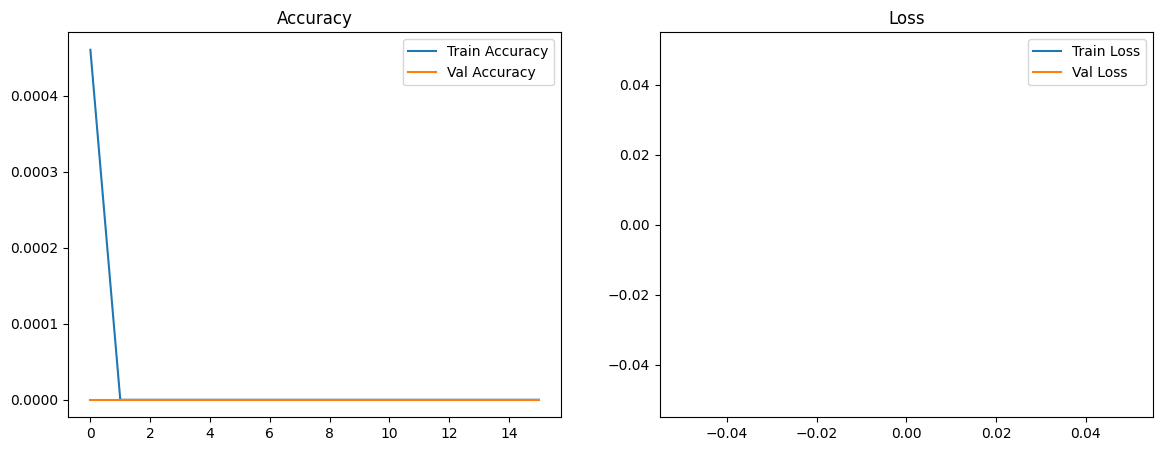

In [8]:
# Training/Validation Accuracy & Loss Plots
plt.figure(figsize=(14,5))
plt.subplot(1,2,1)
plt.plot(history.history['accuracy'], label='Train Accuracy')
plt.plot(history.history['val_accuracy'], label='Val Accuracy')
plt.legend(); plt.title('Accuracy')
plt.subplot(1,2,2)
plt.plot(history.history['loss'], label='Train Loss')
plt.plot(history.history['val_loss'], label='Val Loss')
plt.legend(); plt.title('Loss')
plt.show()

102/102 ━━━━━━━━━━━━━━━━━━━━ 23s 189ms/step


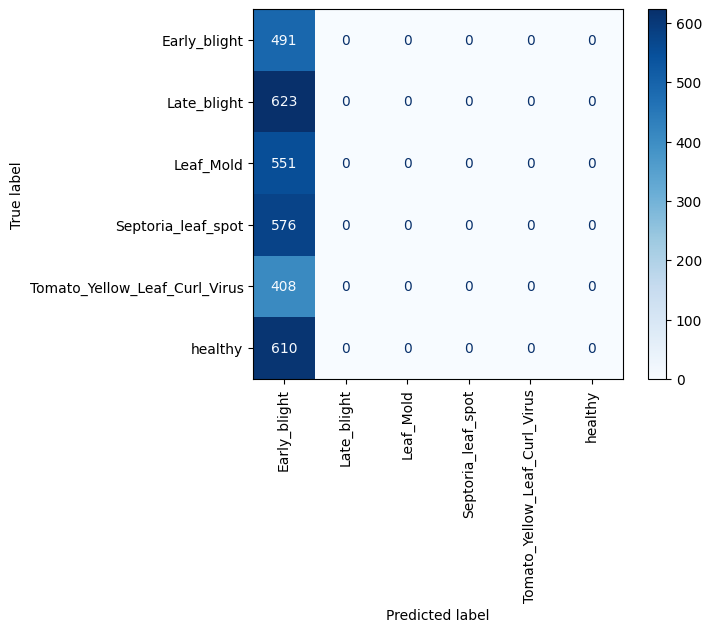

In [9]:
# Confusion Matrix
y_pred = np.argmax(model.predict(X_val), axis=1)
cm = confusion_matrix(y_val, y_pred)
disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=classes)
disp.plot(cmap='Blues', xticks_rotation=90)
plt.show()

In [10]:
def prepare(filepath):
    img = cv2.imread(filepath, cv2.IMREAD_COLOR)
    img = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)
    img = cv2.resize(img, (IMG_SIZE, IMG_SIZE))
    img = img.astype(np.float32) / 255.0
    return img.reshape(1, IMG_SIZE, IMG_SIZE, 3)

Image: mold.jpeg | Predicted: Early_blight (nan%)
  1. healthy: nan%
  2. Tomato_Yellow_Leaf_Curl_Virus: nan%
  3. Septoria_leaf_spot: nan%


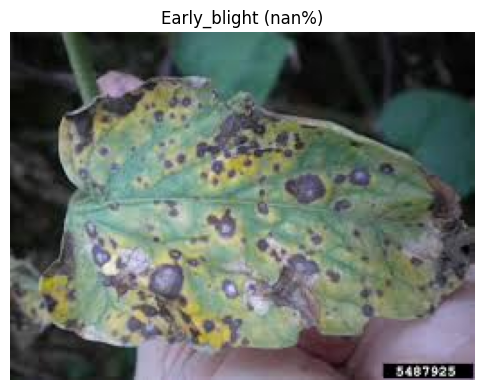

Image: late-blight.jpeg | Predicted: Early_blight (nan%)
  1. healthy: nan%
  2. Tomato_Yellow_Leaf_Curl_Virus: nan%
  3. Septoria_leaf_spot: nan%


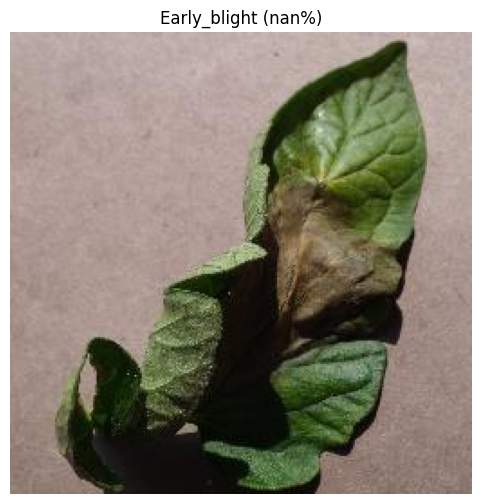

Image: early_blight2.jpeg | Predicted: Early_blight (nan%)
  1. healthy: nan%
  2. Tomato_Yellow_Leaf_Curl_Virus: nan%
  3. Septoria_leaf_spot: nan%


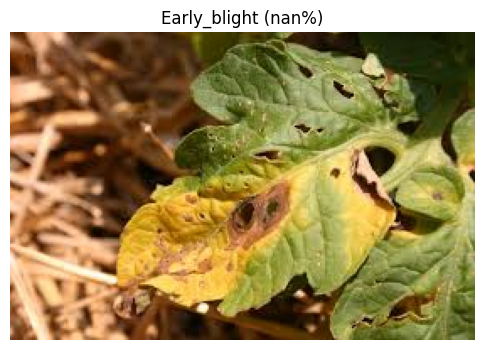

Image: yellow.jpeg | Predicted: Early_blight (nan%)
  1. healthy: nan%
  2. Tomato_Yellow_Leaf_Curl_Virus: nan%
  3. Septoria_leaf_spot: nan%


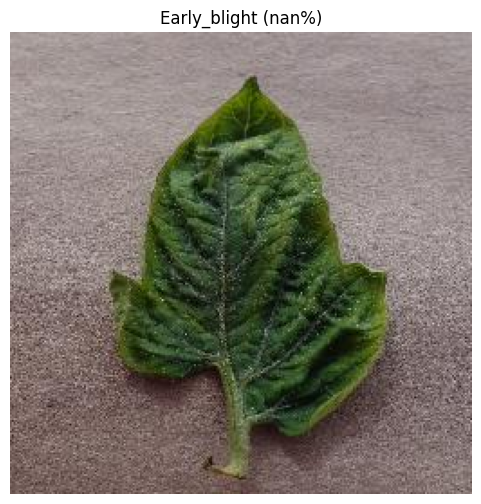

Image: sept2.jpeg | Predicted: Early_blight (nan%)
  1. healthy: nan%
  2. Tomato_Yellow_Leaf_Curl_Virus: nan%
  3. Septoria_leaf_spot: nan%


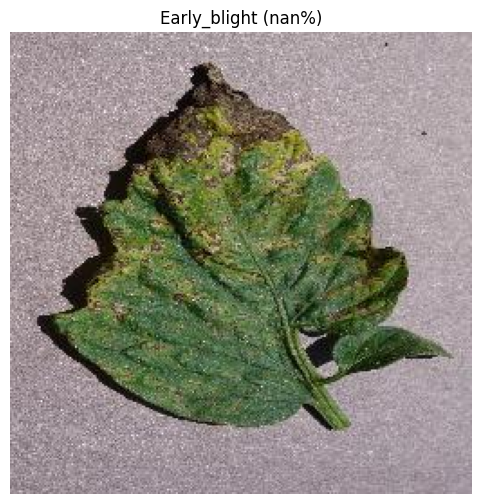

Image: curl.jpeg | Predicted: Early_blight (nan%)
  1. healthy: nan%
  2. Tomato_Yellow_Leaf_Curl_Virus: nan%
  3. Septoria_leaf_spot: nan%


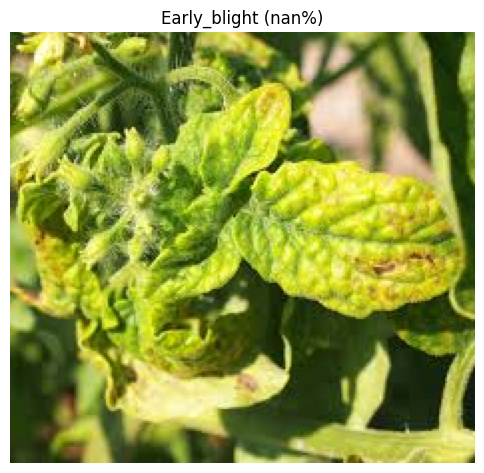

Image: yello_leaf.jpeg | Predicted: Early_blight (nan%)
  1. healthy: nan%
  2. Tomato_Yellow_Leaf_Curl_Virus: nan%
  3. Septoria_leaf_spot: nan%


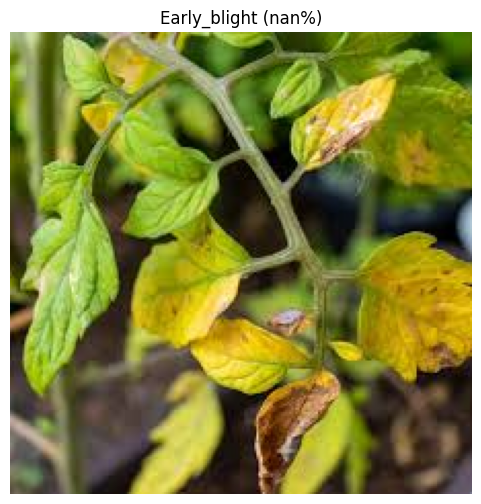

Image: early_blight.jpeg | Predicted: Early_blight (nan%)
  1. healthy: nan%
  2. Tomato_Yellow_Leaf_Curl_Virus: nan%
  3. Septoria_leaf_spot: nan%


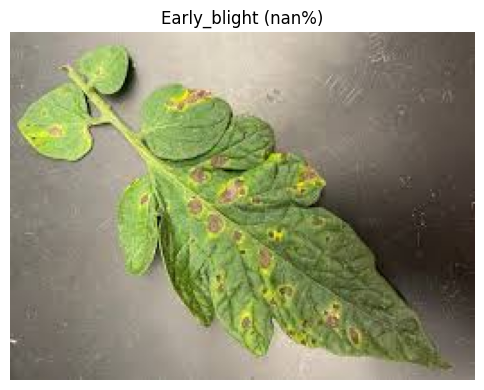

Image: mold2.jpeg | Predicted: Early_blight (nan%)
  1. healthy: nan%
  2. Tomato_Yellow_Leaf_Curl_Virus: nan%
  3. Septoria_leaf_spot: nan%


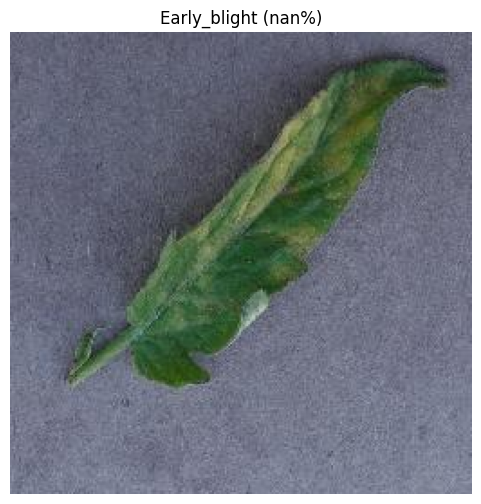

Image: early-blight3.jpeg | Predicted: Early_blight (nan%)
  1. healthy: nan%
  2. Tomato_Yellow_Leaf_Curl_Virus: nan%
  3. Septoria_leaf_spot: nan%


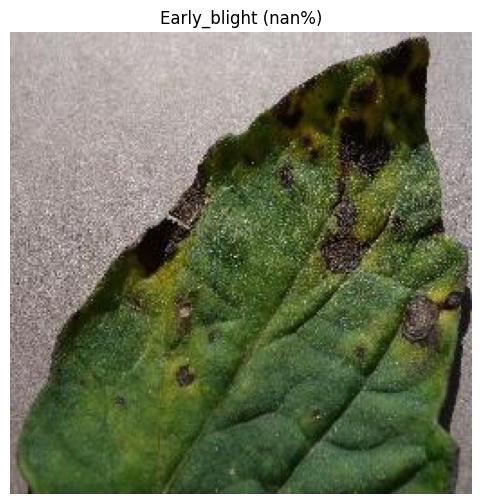

Image: sept.jpeg | Predicted: Early_blight (nan%)
  1. healthy: nan%
  2. Tomato_Yellow_Leaf_Curl_Virus: nan%
  3. Septoria_leaf_spot: nan%


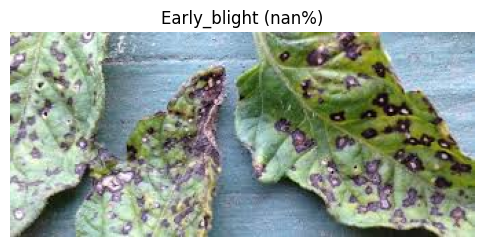

In [11]:
# Multi-image test
TEST_DIR = 'test/'
if os.path.exists(TEST_DIR):
    for img_name in os.listdir(TEST_DIR):
        img_path = os.path.join(TEST_DIR, img_name)
        try:
            prediction = model.predict(prepare(img_path), verbose=0)
            predicted_class_idx = np.argmax(prediction)
            predicted_class = classes[predicted_class_idx]
            confidence = np.max(prediction) * 100
            print(f'Image: {img_name} | Predicted: {predicted_class} ({confidence:.2f}%)')
            top3_idx = np.argsort(prediction[0])[-3:][::-1]
            for i, idx in enumerate(top3_idx):
                print(f'  {i+1}. {classes[idx]}: {prediction[0][idx]*100:.2f}%')
            img_display = cv2.imread(img_path)
            img_display = cv2.cvtColor(img_display, cv2.COLOR_BGR2RGB)
            plt.figure(figsize=(6,6))
            plt.imshow(img_display)
            plt.title(f'{predicted_class} ({confidence:.2f}%)')
            plt.axis('off')
            plt.show()
        except Exception as e:
            print(f'Error processing {img_name}: {e}')